<a href="https://colab.research.google.com/github/O-suke12/ObjectDetection/blob/main/BoundingBoxRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch.nn as nn
import torch
import pandas as pd
from PIL import Image
import os
import numpy as np
from google.colab import files

# **Reference**

Dataset: https://www.kaggle.com/datasets/sshikamaru/car-object-detection

# **Datasets**

kaggle.json

In [ ]:
if os.path.exists("kaggle.json"):
  print("already exist")
else:
  uploaded = files.upload()
  ! mkdir ~/.kaggle
  ! cp kaggle.json ~/.kaggle/
  ! chmod 600 ~/.kaggle/kaggle.json
  ! kaggle datasets download -d sshikamaru/car-object-detection
  ! unzip  car-object-detection

mkdir: cannot create directory ‘/root/.kaggle’: File exists
cp: cannot stat 'kaggle.json': No such file or directory
100% 112M/112M [00:01<00:00, 107MB/s]
100% 112M/112M [00:01<00:00, 113MB/s]
Archive:  car-object-detection.zip
  inflating: data/sample_submission.csv  
  inflating: data/testing_images/vid_5_25100.jpg  
  inflating: data/testing_images/vid_5_25120.jpg  
  inflating: data/testing_images/vid_5_25140.jpg  
  inflating: data/testing_images/vid_5_25160.jpg  
  inflating: data/testing_images/vid_5_25180.jpg  
  inflating: data/testing_images/vid_5_25200.jpg  
  inflating: data/testing_images/vid_5_25220.jpg  
  inflating: data/testing_images/vid_5_25240.jpg  
  inflating: data/testing_images/vid_5_25260.jpg  
  inflating: data/testing_images/vid_5_26320.jpg  
  inflating: data/testing_images/vid_5_26400.jpg  
  inflating: data/testing_images/vid_5_26420.jpg  
  inflating: data/testing_images/vid_5_26560.jpg  
  inflating: data/testing_images/vid_5_26580.jpg  
  inflating: dat

torch.Size([3, 380, 676])
tensor([[ 10, 196,  63, 223]], dtype=torch.int32)


<ipython-input-55-77a75512455e>:11: DeprecationWarning: an integer is required (got type numpy.float64).  Implicit conversion to integers using __int__ is deprecated, and may be removed in a future version of Python.
  bbox = torch.tensor(bbox, dtype=torch.int)


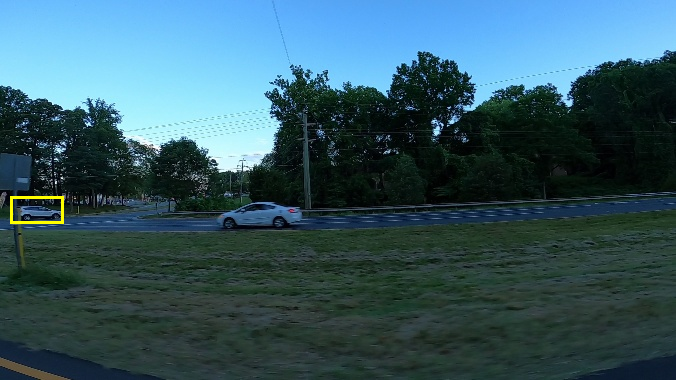

In [ ]:
import torchvision
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes

select_row = 500
df = pd.read_csv("/content/data/train_solution_bounding_boxes (1).csv")
select = bbox = df.iloc[select_row,0]
img = read_image('/content/data/training_images/'+str(select))
print(img.size())
bbox = df.iloc[select_row,1:5]
bbox = torch.tensor(bbox, dtype=torch.int)
bbox=bbox.unsqueeze(0)
print(bbox)
img=draw_bounding_boxes(img, bbox, width=3, colors=(255,255,0))
img = torchvision.transforms.ToPILImage()(img)
img.show()

In [ ]:
from sklearn.model_selection import train_test_split
df[["xmax","xmin"]]/=676
df[["ymax","ymin"]]/=380
df_train, df_test = train_test_split(df, test_size=0.2)
df_train = df_train.reset_index(drop=True)

# **Delete redundunt image**

In [ ]:
import glob, os
from torchvision import datasets, transforms

os.chdir("/content/data/training_images")
dict = {"jpg":[]}
df_all= pd.DataFrame(dict)
for file in glob.glob("*.jpg"):
  df_all.loc[len(df_all.index)] = [file]

In [ ]:
df_all.sort_values('jpg')

,jpg
933,vid_4_10080.jpg
86,vid_4_10160.jpg
848,vid_4_10180.jpg
818,vid_4_10200.jpg
294,vid_4_10220.jpg
...,...
593,vid_4_9400.jpg
317,vid_4_9480.jpg
171,vid_4_9680.jpg
653,vid_4_9920.jpg


In [ ]:
df_train.sort_values('image')

,image,xmin,ymin,xmax,ymax
303,vid_4_10000.jpg,0.022431,0.492198,0.178003,0.622185
285,vid_4_10020.jpg,0.734443,0.453588,0.931983,0.609315
255,vid_4_10040.jpg,0.353835,0.465171,0.535456,0.622185
324,vid_4_10060.jpg,0.024602,0.490911,0.196093,0.627333
292,vid_4_10100.jpg,0.662084,0.422699,0.861071,0.611889
...,...,...,...,...,...
203,vid_4_9840.jpg,0.201748,0.505060,0.369993,0.621640
256,vid_4_9880.jpg,0.487983,0.411796,0.793882,0.659205
374,vid_4_9900.jpg,0.000000,0.442884,0.209760,0.629412
417,vid_4_9960.jpg,0.721049,0.453246,0.912600,0.602210


In [ ]:
cond = df_all['jpg'].isin(df_train['image'])
df_all.drop(df_all[cond].index, inplace = True)

In [ ]:
count = 0
for name in df_all["jpg"]:
  if os.path.exists("/content/data/training_images/"+name):
    os.remove("/content/data/training_images/"+name)
  else:
    if count != 1:
      print("already deleted")
    count = 1

already deleted


# **Cunstom dataset**

In [ ]:
df_train

,image,xmin,ymin,xmax,ymax
0,vid_4_2180.jpg,0.000267,0.001370,0.000502,0.001675
1,vid_4_22240.jpg,0.000059,0.001339,0.000381,0.001754
2,vid_4_26400.jpg,0.001076,0.001268,0.001284,0.001519
3,vid_4_13660.jpg,0.001249,0.001219,0.001479,0.001658
4,vid_4_17620.jpg,0.000924,0.001224,0.001246,0.001617
...,...,...,...,...,...
442,vid_4_14480.jpg,0.000334,0.001319,0.000553,0.001590
443,vid_4_620.jpg,0.000043,0.001343,0.000248,0.001616
444,vid_4_1980.jpg,0.000770,0.001316,0.000984,0.001603
445,vid_4_12200.jpg,0.000945,0.001224,0.001018,0.001393


In [ ]:
from torch.utils.data import Dataset
import xml.etree.ElementTree as ET
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.io import read_image


preprocess = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor() 
])

class CustomImageDataset(Dataset):
    def __init__(self, img_dir, annotations_file, transform=True, target_transform=None):
        self.df= annotations_file
        self.img_dir = img_dir
        self.transform = transform
     

    def __len__(self):
      return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir+"/"+ (self.df.iloc[idx, 0]))
        image = Image.open(img_path)
        bbox = df.iloc[idx, 1:]
        image = self.transform(image)
        return image, bbox.to_numpy()
        
CID = CustomImageDataset("/content/data/training_images", df_train, preprocess)
CID.__getitem__(0)

train_loader = DataLoader(CID, batch_size=1,
                        shuffle=True, num_workers=0, drop_last=True)

# **Model**

In [ ]:
class BBR(nn.Module):
  def __init__(self):
    super().__init__()
    self.alex = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=True)

    self.bbr = nn.Sequential(
        nn.Linear(in_features=1000, out_features=512),
        nn.ReLU(),
        nn.Linear(in_features=512, out_features=256),
        nn.ReLU(),
        nn.Linear(in_features=256, out_features=128),
        nn.ReLU(),
        nn.Linear(in_features=128, out_features=32),
        nn.ReLU(),
        nn.Linear(in_features=32, out_features=4),
    )

  def forward(self, X):
    X = self.alex(X)
    X = self.bbr(X)
    return torch.sigmoid(X)

model = BBR()


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


# **Training and Evaluation**

In [ ]:
from torchvision import transforms
import torch.fft
from sklearn.model_selection import KFold 

epochs =  3
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
# kf = KFold(n_splits=10, random_state=None)

for epoch in range(epochs):

  for batch, bbox in train_loader:
    model.train()
    print(batch, bbox)
    y_pred = model()




# for train_index , valid_index in kf.split(df_train):
#   X_train , X_valid = df_train.iloc[train_index,:],df_train.iloc[valid_index,:]
#   X_train = X_train.reset_index(drop=True)
#   X_valid = X_valid.reset_index(drop=True)

#   model.train()
#   select_index = np.random.randint(0,len(df_train), size=BATCH_SIZE)
#   loss = 0
#   train_loss = 0

#   select_index = np.random.randint(0,len(X_train),BATCH_SIZE)
#   select_label = torch.tensor(X_train.iloc[select_index,1:5].values).to(torch.float32)
#   image_list = [torch.unsqueeze(read_image('/content/data/training_images/'+str(X_train.iloc[i][0])),0)/255. for i in select_index]
#   for batch, y_label in zip(image_list, select_label):
#     y_pred = model(batch.to(torch.float32))
#     optimizer.zero_grad()
#     print(y_pred)
#     loss = loss_fn(y_pred, y_label)
#     train_loss += loss
#     loss.backward()
#     optimizer.step()  
#   print("train_loss",train_loss)

#   with torch.inference_mode():
#     valid_loss = 0
#     select_index = np.random.randint(0,len(X_valid), 10)
#     select_label = torch.tensor(X_train.iloc[select_index,1:5].values).to(torch.float32)
#     image_list = [torch.unsqueeze(read_image('/content/data/training_images/'+str(X_valid.iloc[i][0])),0)/255. for i in select_index]
#     for batch, valid_label in zip(image_list, select_label):
#       valid_pred = model(batch.to(torch.float32))
#       valid_loss += loss_fn(valid_pred, valid_label)
      
#     print("valid_loss",valid_loss)

FileNotFoundError: ignored

In [ ]:
train_loss_set

In [ ]:
sample_optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
np.random.seed(2)

model.train()
select_index = np.random.randint(0,len(df_train),3)
sample_X = [torch.unsqueeze(read_image('/content/data/training_images/'+str(df_train.iloc[i][0])),0)/255. for i in select_index]
sample_label = torch.tensor(df_train.iloc[select_index,1:5].values.astype(np.float32)).to(torch.float32)
sample_X = torch.cat(sample_X).to(torch.float32)

sample_optimizer.zero_grad()
sample_pred = model(sample_X)
# print("label",torch.mean(sample_label,0))
print("label", sample_label)
print("pred",sample_pred)

sample_loss = loss_fn(sample_pred, sample_label)
print(sample_loss)
sample_loss.backward()
sample_optimizer.step()  

In [ ]:
loss_fn(torch.tensor([0.4269, 0.4793, 0.6375, 0.6196]), torch.tensor([0.3331, 0.4840, 0.4784, 0.5962]))

In [ ]:
0.0248*0.0248

In [ ]:
import torchvision
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes

select_index = np.random.randint(0,len(df_train))
select = df_train.iloc[select_index,0]
img= read_image('/content/data/training_images/'+str(select))
label = df.iloc[select_row,1:5]
bbox = model((img.to(torch.float32)/255.).unsqueeze(0))
bbox[0][0] *= 676
bbox[0][1] *= 380
bbox[0][2] *= 676
bbox[0][3] *= 380
label = torch.tensor(bbox, dtype=torch.int)
print(bbox)
print(label)
img= draw_bounding_boxes(img, label, width=3, colors=(255,255,0))
img = torchvision.transforms.ToPILImage()(img)
img.show()